# Databases and SQL

## 1. Setup & Imports

In [42]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

In [43]:
#Create the database file in the Data folder
DB_PATH = '../Data/ky_air_asthma.db'
os.makedirs('../Data', exist_ok=True)

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()
print(f'Database created at: {DB_PATH}')

Database created at: ../Data/ky_air_asthma.db


## 2. Load in Data

In [44]:
#Load in data
annual_er_visitis = pd.read_csv('../Data/Annual_ER_Visits_For_Asthma.csv')
annual_hospitalizations = pd.read_csv('../Data/Annual_Hospitalizations_for_Asthma.csv')
ky_aqi = pd.read_csv('../Data/daily_aqi_by_county_2022.csv')

#Make some column names more consistent across datasets

#EPA daily AQI uses 'county Name' and 'State Name' with unusual casing
ky_aqi = ky_aqi.rename(columns={'county Name': 'County', 'State Name': 'State', 'Category': 'AQI Category'})
#Parse year from the Date column (format: YYYY-MM-DD)
ky_aqi['Date'] = pd.to_datetime(ky_aqi['Date'])
ky_aqi['Year'] = ky_aqi['Date'].dt.year

#Clean up the data
counties_of_interest = ['Fayette', 'Pulaski', 'Pike', 'Warren']

kentucky_er_visits = annual_er_visitis[
    annual_er_visitis['County'].isin(counties_of_interest)
].copy()

kentucky_hospitalizations = annual_hospitalizations[
    annual_hospitalizations['State'] == 'Kentucky'
].copy()

ky_aqi_counties = ky_aqi[
    ky_aqi['County'].isin(counties_of_interest)
].copy()

ky_selected_counties = ky_aqi.groupby(['State', 'County', 'Year'], as_index=False).agg(
    days_with_aqi=('AQI', 'count'),
    good_days=('AQI Category', lambda x: (x == 'Good').sum()),
    moderate_days=('AQI Category', lambda x: (x == 'Moderate').sum()),
    max_aqi=('AQI', 'max'),
    percentile_90_aqi=('AQI', lambda x: x.quantile(0.9)),
    median_aqi=('AQI', 'median')
)
ky_selected_counties = ky_selected_counties[
    ky_selected_counties['County'].isin(counties_of_interest)
].copy()

print('Data loaded successfully.')
print(f'  Daily AQI rows : {len(ky_aqi_counties)}')
print(f'  Annual AQI rows: {len(ky_selected_counties)}')
print(f'  ER visit rows  : {len(kentucky_er_visits)}')
print(f'  Hosp. rows     : {len(kentucky_hospitalizations)}')

Data loaded successfully.
  Daily AQI rows : 3306
  Annual AQI rows: 10
  ER visit rows  : 4
  Hosp. rows     : 10


## 3. Entity Relationship Diagram (ERD)

Can be found in the End Visualizations folder, created using Lucid Chart.

- Schema Justification:<br>

    > This relational database contains four different counties as samples from four different KY regions, this correlates to the "counties" section of the schema. This is the parent of "daily_aqi", "annual_aqi", and "er_visits". "hospitalizations" does not have a "counties" column due to it being state level data, therefore it is related but not directly correlatory to "counties" and is its own parent. This layout directly correlates to how the visualizations and the analysis was completed.

## 4. Build the Database Schema

In [45]:
#Drop tables if re-running this notebook
cursor.executescript('''
    DROP TABLE IF EXISTS hospitalizations;
    DROP TABLE IF EXISTS er_visits;
    DROP TABLE IF EXISTS annual_aqi;
    DROP TABLE IF EXISTS daily_aqi;
    DROP TABLE IF EXISTS counties;
''')

#Counties
cursor.execute('''
    CREATE TABLE counties (
        county_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        county_name TEXT    NOT NULL,
        state       TEXT    NOT NULL,
        UNIQUE (county_name, state)
    )
''')

#Daily AQI
cursor.execute('''
    CREATE TABLE daily_aqi (
        aqi_id    INTEGER PRIMARY KEY AUTOINCREMENT,
        county_id INTEGER NOT NULL REFERENCES counties(county_id),
        date      TEXT    NOT NULL,
        aqi       INTEGER NOT NULL,
        category  TEXT    NOT NULL
    )
''')

#Annual AQI Summary
cursor.execute('''
    CREATE TABLE annual_aqi (
        annual_id     INTEGER PRIMARY KEY AUTOINCREMENT,
        county_id     INTEGER NOT NULL REFERENCES counties(county_id),
        year          INTEGER NOT NULL,
        days_with_aqi INTEGER,
        good_days     INTEGER,
        moderate_days INTEGER,
        max_aqi       INTEGER,
        pct90_aqi     REAL,
        median_aqi    REAL
    )
''')

#County level ER Visits
cursor.execute('''
    CREATE TABLE er_visits (
        visit_id  INTEGER PRIMARY KEY AUTOINCREMENT,
        county_id INTEGER NOT NULL REFERENCES counties(county_id),
        year      INTEGER NOT NULL,
        er_visits INTEGER NOT NULL
    )
''')

#State level hospitalizations (no county data available)
cursor.execute('''
    CREATE TABLE hospitalizations (
        hosp_id     INTEGER PRIMARY KEY AUTOINCREMENT,
        state       TEXT    NOT NULL,
        year        INTEGER NOT NULL,
        age_group   TEXT    NOT NULL,
        sex         TEXT    NOT NULL,
        hosp_count  INTEGER NOT NULL
    )
''')

conn.commit()
print('Schema created successfully — 5 tables.')

Schema created successfully — 5 tables.


## 5. Populate the Tables

In [46]:
#Find our counties in the counties table, inserting if they don't exist
for county in counties_of_interest:
    cursor.execute(
        'INSERT OR IGNORE INTO counties (county_name, state) VALUES (?, ?)',
        (county, 'Kentucky')
    )
conn.commit()

#Build a lookup dict: county_name -> county_id
county_id_map = {
    row[0]: row[1]
    for row in cursor.execute('SELECT county_name, county_id FROM counties').fetchall()
}
print('County IDs:', county_id_map)

#Insert daily AQI readings
daily_rows = [
    (county_id_map[row['County']], str(row['Date'].date()), int(row['AQI']), row['AQI Category'])
    for _, row in ky_aqi_counties.iterrows()
]
cursor.executemany(
    'INSERT INTO daily_aqi (county_id, date, aqi, category) VALUES (?, ?, ?, ?)',
    daily_rows
)

#Insert annual AQI summaries
annual_rows = [
    (
        county_id_map[row['County']],
        int(row['Year']),
        int(row['days_with_aqi']),
        int(row['good_days']),
        int(row['moderate_days']),
        int(row['max_aqi']),
        round(float(row['percentile_90_aqi']), 1),
        round(float(row['median_aqi']), 1)
    )
    for _, row in ky_selected_counties.iterrows()
]
cursor.executemany(
    '''INSERT INTO annual_aqi
       (county_id, year, days_with_aqi, good_days, moderate_days, max_aqi, pct90_aqi, median_aqi)
       VALUES (?, ?, ?, ?, ?, ?, ?, ?)''',
    annual_rows
)

#Insert ER visits
er_rows = [
    (county_id_map[row['County']], int(row['Year']), int(str(row['Value']).replace(',', '').strip()))
    for _, row in kentucky_er_visits.iterrows()
    if row['County'] in county_id_map
]
cursor.executemany(
    'INSERT INTO er_visits (county_id, year, er_visits) VALUES (?, ?, ?)',
    er_rows
)

#Insert hospitalizations
def parse_age_sex(raw):
    """Split the 'Age Group\"Sex' field (e.g. '5 TO 14\"Male') into age_group and sex."""
    raw = str(raw).strip()
    #The column uses a literal quote character as a delimiter between age and sex
    if '"' in raw:
        parts = raw.split('"')
        return parts[0].strip(), parts[1].strip()
    #Fallback: try splitting on last word
    for sex in ['Male', 'Female']:
        if raw.endswith(sex):
            return raw[: -len(sex)].strip(), sex
    return raw, 'Unknown'

hosp_rows = []
for _, row in kentucky_hospitalizations.iterrows():
    age_group, sex = parse_age_sex(row['Age Group"Sex'])
    hosp_rows.append(('Kentucky', int(row['Year']), age_group, sex, int(row['Value'])))

cursor.executemany(
    'INSERT INTO hospitalizations (state, year, age_group, sex, hosp_count) VALUES (?, ?, ?, ?, ?)',
    hosp_rows
)

conn.commit()
print('All tables populated.')

County IDs: {'Fayette': 1, 'Pulaski': 2, 'Pike': 3, 'Warren': 4}
All tables populated.


## 6. Verify Row Counts

In [47]:
tables = ['counties', 'daily_aqi', 'annual_aqi', 'er_visits', 'hospitalizations']
for t in tables:
    count = cursor.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    print(f'  {t:<20} {count:>5} rows')

  counties                 4 rows
  daily_aqi             3306 rows
  annual_aqi              10 rows
  er_visits                4 rows
  hospitalizations        10 rows


---
## 7. SQL Queries

### Query 1 — Which county had the most "Moderate" or worse air quality days in 2022?

In [48]:
query1 = '''
    SELECT
        c.county_name,
        COUNT(d.aqi_id)  AS unhealthy_days,
        ROUND(AVG(d.aqi), 1) AS avg_aqi_on_bad_days
    FROM daily_aqi d
    JOIN counties c ON d.county_id = c.county_id
    WHERE d.category != 'Good'
    GROUP BY c.county_name
    ORDER BY unhealthy_days DESC
'''
q1 = pd.read_sql_query(query1, conn)
print('Counties ranked by number of non-Good AQI days (2022):')
print(q1.to_string(index=False))

Counties ranked by number of non-Good AQI days (2022):
county_name  unhealthy_days  avg_aqi_on_bad_days
     Warren             362                 59.4
    Pulaski             312                 58.9
    Fayette             216                 58.6
       Pike              98                 57.9


### Query 2 — Join air quality summaries with ER visit counts per county

In [49]:
query2 = '''
    SELECT
        c.county_name,
        a.median_aqi,
        a.max_aqi,
        a.moderate_days,
        e.er_visits
    FROM annual_aqi a
    JOIN counties  c ON a.county_id = c.county_id
    JOIN er_visits e ON e.county_id = c.county_id AND e.year = a.year
    WHERE a.year = 2022
    ORDER BY e.er_visits DESC
'''
q2 = pd.read_sql_query(query2, conn)
print('Air quality vs. ER visits by county (2022):')
print(q2.to_string(index=False))

Air quality vs. ER visits by county (2022):
county_name  median_aqi  max_aqi  moderate_days  er_visits
    Fayette        44.0      106            129       1104
    Fayette        34.5       64              2       1104
    Fayette        43.0       87             84       1104
     Warren        43.0       84            115        305
     Warren        43.0       86            122        305
     Warren        44.0      133            122        305
    Pulaski        52.0      115            211        160
    Pulaski        42.0       82            100        160
       Pike        35.0      100             29         90
       Pike        39.0       92             69         90


### Query 3 — Which months had the highest average AQI across all counties?

In [50]:
query3 = '''
    SELECT
        CAST(SUBSTR(d.date, 6, 2) AS INTEGER) AS month,
        ROUND(AVG(d.aqi), 1)                  AS avg_aqi,
        MAX(d.aqi)                            AS peak_aqi,
        COUNT(d.aqi_id)                       AS reading_count
    FROM daily_aqi d
    GROUP BY month
    ORDER BY month
'''
q3 = pd.read_sql_query(query3, conn)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
q3['month_name'] = q3['month'].apply(lambda m: month_names[m - 1])
print('Monthly average AQI across all four counties (2022):')
print(q3[['month_name','avg_aqi','peak_aqi','reading_count']].to_string(index=False))

Monthly average AQI across all four counties (2022):
month_name  avg_aqi  peak_aqi  reading_count
       Jan     42.4        82            305
       Feb     41.5        70            271
       Mar     44.3       115            308
       Apr     43.1        92            297
       May     43.5        90            288
       Jun     55.5       133            270
       Jul     47.9        93            268
       Aug     41.8        71            279
       Sep     40.3        71            270
       Oct     40.0        75            277
       Nov     43.6       106            230
       Dec     37.0        86            243


### Query 4 — What share of each county's days fell into each AQI category?

In [51]:
query4 = '''
    SELECT
        c.county_name,
        COUNT(*) AS total_days,
        ROUND(100.0 * SUM(CASE WHEN d.category = 'Good'     THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_good,
        ROUND(100.0 * SUM(CASE WHEN d.category = 'Moderate' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_moderate,
        ROUND(100.0 * SUM(CASE WHEN d.category NOT IN ('Good','Moderate') THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_unhealthy
    FROM daily_aqi d
    JOIN counties c ON d.county_id = c.county_id
    GROUP BY c.county_name
    ORDER BY pct_good DESC
'''
q4 = pd.read_sql_query(query4, conn)
print('AQI category breakdown by county (% of days):')
print(q4.to_string(index=False))

AQI category breakdown by county (% of days):
county_name  total_days  pct_good  pct_moderate  pct_unhealthy
       Pike         705      86.1          13.9            0.0
    Fayette         795      72.8          27.0            0.1
     Warren        1082      66.5          33.2            0.3
    Pulaski         724      56.9          43.0            0.1


### Query 5 — Which age groups had the highest asthma hospitalization counts in Kentucky?

In [52]:
query5 = '''
    SELECT
        age_group,
        sex,
        SUM(hosp_count) AS total_hospitalizations
    FROM hospitalizations
    WHERE state = 'Kentucky'
    GROUP BY age_group, sex
    ORDER BY total_hospitalizations DESC
'''
q5 = pd.read_sql_query(query5, conn)
print('Kentucky asthma hospitalizations by age group and sex (2022):')
print(q5.to_string(index=False))

Kentucky asthma hospitalizations by age group and sex (2022):
age_group    sex  total_hospitalizations
  5 TO 14   Male                     200
   0 TO 4   Male                     180
 35 TO 64 Female                     167
  5 TO 14 Female                     134
   0 TO 4 Female                     111
 15 TO 34 Female                      91
    >= 65 Female                      89
 35 TO 64   Male                      54
 15 TO 34   Male                      50
    >= 65   Male                      21


### Query 6 — Identify high-risk days: AQI above 50 during the third week of September (Asthma Peak Week)

In [53]:
query6 = '''
    SELECT
        c.county_name,
        d.date,
        d.aqi,
        d.category
    FROM daily_aqi d
    JOIN counties c ON d.county_id = c.county_id
    WHERE
        SUBSTR(d.date, 6, 5) BETWEEN '09-15' AND '09-21'
        AND d.aqi > 50
    ORDER BY d.aqi DESC
'''
q6 = pd.read_sql_query(query6, conn)
if q6.empty:
    print('No AQI readings above 50 during Asthma Peak Week (Sep 15-21, 2022).')
    print('This suggests 2022 peak week had relatively good air quality in these counties.')
else:
    print('High-AQI days during Asthma Peak Week (Sep 15-21, 2022):')
    print(q6.to_string(index=False))

High-AQI days during Asthma Peak Week (Sep 15-21, 2022):
county_name       date  aqi category
       Pike 2022-09-19   71 Moderate
    Pulaski 2022-09-16   69 Moderate
    Pulaski 2022-09-17   69 Moderate
    Fayette 2022-09-20   67 Moderate
    Pulaski 2022-09-15   64 Moderate
     Warren 2022-09-15   64 Moderate
     Warren 2022-09-19   62 Moderate
    Pulaski 2022-09-18   61 Moderate
    Fayette 2022-09-17   61 Moderate
    Pulaski 2022-09-20   59 Moderate
    Pulaski 2022-09-19   59 Moderate
    Fayette 2022-09-16   58 Moderate
     Warren 2022-09-18   58 Moderate
     Warren 2022-09-20   58 Moderate
     Warren 2022-09-18   58 Moderate
    Fayette 2022-09-16   58 Moderate
    Fayette 2022-09-18   57 Moderate
    Pulaski 2022-09-18   57 Moderate
     Warren 2022-09-19   57 Moderate
     Warren 2022-09-21   56 Moderate
     Warren 2022-09-16   56 Moderate
     Warren 2022-09-18   56 Moderate
    Fayette 2022-09-18   56 Moderate
    Pulaski 2022-09-19   55 Moderate
    Pulaski 2022-0

### A unique function that shows the annual AQI summary of statistics for a specific county in KY

In [54]:
def get_county_aqi_summary(conn, county_name):
    """
    Retrieve the annual AQI summary of statistics for a specific Kentucky county.

    Joins the annual_aqi table with the counties table to return
    a single row containing good days, moderate days, max AQI, 90th percentile
    AQI, and median AQI for the requested county.

    Parameters
    ----------
    conn        : sqlite3.Connection  Active connection to the SQLite database.
    county_name : str                 Name of the county (e.g. 'Fayette', 'Pike').

    Returns
    -------
    pd.DataFrame  One row per year on record for that county, or an empty
                  DataFrame if the county is not found.
    """
    sql = '''
        SELECT
            c.county_name,
            a.year,
            a.days_with_aqi,
            a.good_days,
            a.moderate_days,
            a.max_aqi,
            a.pct90_aqi,
            a.median_aqi
        FROM annual_aqi a
        JOIN counties c ON a.county_id = c.county_id
        WHERE c.county_name = ?
    '''
    return pd.read_sql_query(sql, conn, params=(county_name,))

In [55]:
get_county_aqi_summary(conn, 'Fayette')

,county_name,year,days_with_aqi,good_days,moderate_days,max_aqi,pct90_aqi,median_aqi
0,Fayette,2022,365,235,129,106,59.6,44.0
1,Fayette,2022,128,126,2,64,46.0,34.5
2,Fayette,2022,302,218,84,87,58.0,43.0


## Visualization Findings

- Monthly Average AQI Across Four Kentucky Counties (2022)

> June is the peak month for air quality burden, with an average air quality index of ~56 making it the only month approaching the upper edge of the "Moderate" range. This aligns with the summer ozone season, where heat and sunlight accelerate the formation of ground-level ozone. Notably, September (the month containing Asthma Peak Week) does not show an elevated air quality index relative to the rest of the year. In fact, it sits right around the annual average (~40-42), and October through December generally trend downward. The air quality data alone does not confirm that mid-September is uniquely hazardous in these four Kentucky counties during 2022.

- Asthma ER Visits and Median AQI by County (2022)

> This chart reveals a disconnect: Fayette County has by far the most asthma emergancy room visits (~1,100) but one of the lower median air quality indeces (~44). Meanwhile, Pulaski has the highest median air quality index (~52) but relatively fewer emergency room visits (~160). This suggests that air quality alone doesn't explain asthma emergency room visit rates — population size is likely the dominant factor, since Fayette (Lexington) is the most populous county in the set by a wide margin. Pike County has both the lowest emergency room visits and the lowest median air quality index, which does fit the expected pattern. Another aspect to this data could be patients that are taken from their local hospitals and moved to other counties (emergency room to emergency room transfers). Fayette county has multiple high level hospitals with comprehensive care teams that are better equipped to take care of more severe cases of asthma exacerbations that turn into hospitalizations. 

In conclusion, air quality and asthma outcomes _are_ related, but confounded by population size and access to care as well as other respiratory upset triggers not related to air quality alone. 

---
## 8. Visualizing Query Results

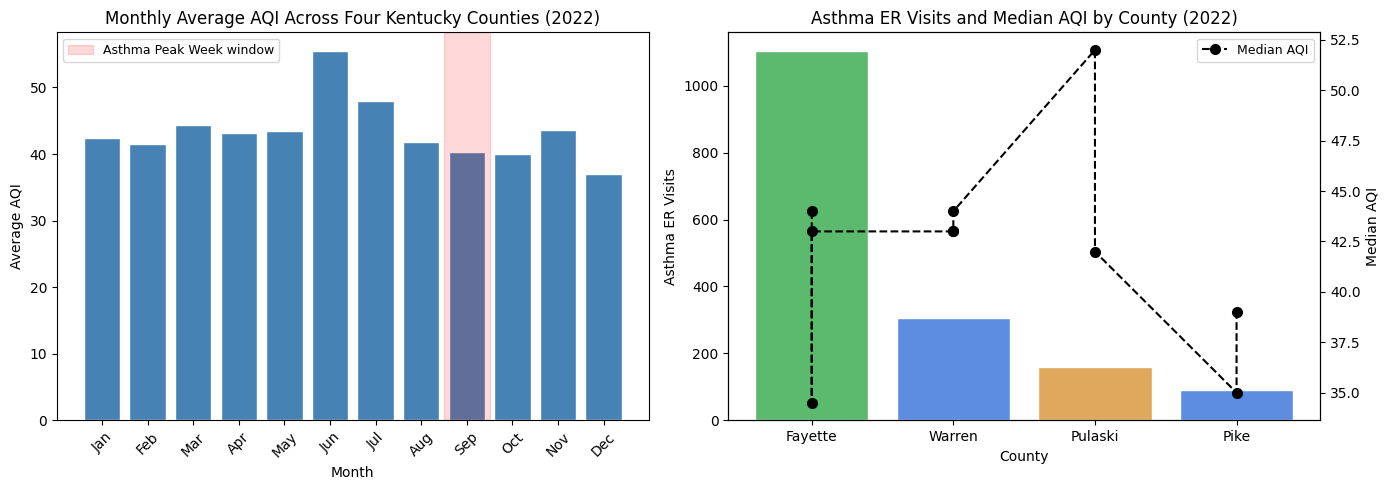

Chart saved to End_Visualizations/sql_query_charts.png


In [56]:
#Monthly average AQI (Query 3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(q3['month_name'], q3['avg_aqi'], color='steelblue', edgecolor='white')
axes[0].axvspan(7.5, 8.5, alpha=0.15, color='red', label='Asthma Peak Week window')
axes[0].set_title('Monthly Average AQI Across Four Kentucky Counties (2022)', fontsize=12)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average AQI')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=45)

#ER visits vs Median AQI (Query 2)
colors = ['#e05c5c', '#5c8de0', '#5cba6e', '#e0a85c']
axes[1].bar(q2['county_name'], q2['er_visits'], color=colors, edgecolor='white')
ax2 = axes[1].twinx()
ax2.plot(q2['county_name'], q2['median_aqi'], 'ko--', linewidth=1.5, markersize=7, label='Median AQI')
axes[1].set_title('Asthma ER Visits and Median AQI by County (2022)', fontsize=12)
axes[1].set_xlabel('County')
axes[1].set_ylabel('Asthma ER Visits', color='black')
ax2.set_ylabel('Median AQI', color='black')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../End_Visualizations/sql_query_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to End_Visualizations/sql_query_charts.png')

## Visualization Findings

- Monthly Average AQI Across Four Kentucky Counties (2022)

> June is the peak month for air quality burden, with an average AQI of ~56 making it the only month approaching the upper edge of the "Moderate" range. This aligns with the summer ozone season, where heat and sunlight accelerate the formation of ground-level ozone. Notably, September (the month containing Asthma Peak Week) does not show an elevated AQI relative to the rest of the year. In fact, it sits right around the annual average (~40-42), and October through December generally trend downward. The air quality data alone does not confirm that mid-September is uniquely hazardous in these four Kentucky counties during 2022.

- Asthma ER Visits and Median AQI by County (2022)

> This chart reveals a disconnect: Fayette County has by far the most asthma ER visits (~1,100) but one of the lower median AQIs (~44). Meanwhile, Pulaski has the highest median AQI (~52) but relatively few ER visits (~160). This suggests that air quality alone doesn't explain asthma ER visit rates — population size is likely the dominant factor, since Fayette (Lexington) is the most populous county in the set by a wide margin. Pike County has both the lowest ER visits and the lowest median AQI, which does fit the expected pattern. Another aspect to this data could be patients that are taken from their local hospitals and moved to other counties (ER to ER transfers). Fayette county has multiple high level hospitals with comprehensive care teams that are better equipped to take care of more severe cases of asthma exacerbations that may turn into hospitalizations. 

In conclusion, air quality and asthma outcomes _are_ related, but confounded by population size and access to care as well as other respiratory upset triggers not related to air quality alone. 

---

## 9. Close Connection

In [57]:
conn.close()
print(f'Database saved to {DB_PATH}')
print('Done.')

Database saved to ../Data/ky_air_asthma.db
Done.
